# 04: Distance metrics: Levenshtein, Jaccard, normalised TED

Continuous distances in `[0, 1]` (0 = identical). Token Levenshtein, token-set Jaccard, and normalised tree-edit distance over a shallow clause tree (APTED) -- all from `harness.distances`, sharing the canonicaliser (`harness.canonical`) with 03. Computed for every target present and shown per target (per-model per-query tables, then a per-target aggregation by model), followed by a run-level summary; the figures keep the targets separate. An identity test (gold vs itself -> all distances 0.0) runs first.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "pyproject.toml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "eval"))

import pandas as pd
from harness import GOLD_DIR, METRICS_DISTANCE_CSV, RECORDS_DIR, load_dataset, load_records
from harness.distances import jaccard, levenshtein, normalized_ted

OUT_CSV = METRICS_DISTANCE_CSV
from harness import plots

## Identity sanity test

In [2]:
identity_rows = []
for ds_path in sorted(GOLD_DIR.glob('*.yaml')):
    for q in load_dataset(ds_path.stem):
        for target, ref in q.expected.items():
            identity_rows.append((ds_path.stem, q.id, target,
                                  levenshtein(ref, ref, target), jaccard(ref, ref, target),
                                  normalized_ted(ref, ref, target)))
identity_df = pd.DataFrame(identity_rows, columns=['dataset','query_id','target','lev','jac','ted'])
non_zero = identity_df[(identity_df[['lev','jac','ted']] > 1e-9).any(axis=1)]
print(f'Identity test: {len(identity_df)} cases; non-zero: {len(non_zero)}')
if len(non_zero):
    display(non_zero)
    raise AssertionError('Identity sanity test failed: a distance metric has a bug.')
print('PASS')

Identity test: 45 cases; non-zero: 0
PASS


## Compute on the real records

In [3]:
records = load_records(RECORDS_DIR)
keys = ['dataset','target','model','query_id','difficulty']
rows = []
for r in records:
    translated = r.get('generated_query')
    expected = r['expected_query']
    target = r['target']
    base = {k: r[k] for k in keys}
    if not translated:
        rows.append({**base, 'levenshtein': 1.0, 'jaccard': 1.0, 'normalized_ted': 1.0})
        continue
    rows.append({**base, 'levenshtein': levenshtein(translated, expected, target),
                 'jaccard': jaccard(translated, expected, target),
                 'normalized_ted': normalized_ted(translated, expected, target)})
dist_df = pd.DataFrame(rows)

## Per-target results

One section per target, one subsection per model: the model's per-query distances, then a per-target aggregation by model. All distances are in [0, 1]; lower is better.

In [4]:
metric_cols = ['levenshtein','jaccard','normalized_ted']

def show_model(target, model):
    """Per-query distances for one (target, model) cell."""
    sub = dist_df[(dist_df['target'] == target) & (dist_df['model'] == model)]
    if not len(sub):
        print(f'No records for {target}/{model} yet.')
        return None
    return sub[['query_id', 'difficulty'] + metric_cols].sort_values('query_id').reset_index(drop=True)

def summarize_target(target):
    """Mean distances for one target, by model (lower is better)."""
    sub = dist_df[dist_df['target'] == target]
    if not len(sub):
        print(f'No records for {target} yet.')
        return None
    return sub.groupby('model')[metric_cols].mean()

## SQL → Cypher

### llama3.2:latest

In [5]:
show_model('cypher', 'llama3.2:latest')

,query_id,difficulty,levenshtein,jaccard,normalized_ted
0,ldbc_q01,easy,0.000000,0.000000,0.000000
1,ldbc_q02,easy,0.489796,0.483871,0.480000
2,ldbc_q03,easy,0.475000,0.375000,0.463415
3,ldbc_q04,hard,0.026316,0.074074,0.026316
4,ldbc_q05,hard,0.571429,0.512195,0.596774
5,ldbc_q06,medium,0.368421,0.310345,0.392857
6,ldbc_q07,medium,0.478261,0.386364,0.473118
7,ldbc_q08,hard,0.652542,0.463415,0.672269
8,ldbc_q09,medium,0.389610,0.250000,0.421053
9,ldbc_q10,hard,0.387755,0.258065,0.395833


### qwen3-coder:30b

In [6]:
show_model('cypher', 'qwen3-coder:30b')

,query_id,difficulty,levenshtein,jaccard,normalized_ted
0,ldbc_q01,easy,0.000000,0.000000,0.000000
1,ldbc_q02,easy,0.000000,0.000000,0.000000
2,ldbc_q03,easy,0.000000,0.000000,0.000000
3,ldbc_q04,hard,0.295455,0.037037,0.295455
4,ldbc_q05,hard,0.621622,0.250000,0.625000
5,ldbc_q06,medium,0.170732,0.115385,0.166667
6,ldbc_q07,medium,0.200000,0.030303,0.197183
7,ldbc_q08,hard,0.119048,0.031250,0.152941
8,ldbc_q09,medium,0.328125,0.205882,0.375000
9,ldbc_q10,hard,0.048780,0.076923,0.050000


### gemma4:26b

In [7]:
show_model('cypher', 'gemma4:26b')

,query_id,difficulty,levenshtein,jaccard,normalized_ted
0,ldbc_q01,easy,0.000000,0.000000,0.000000
1,ldbc_q02,easy,0.000000,0.000000,0.000000
2,ldbc_q03,easy,0.000000,0.000000,0.000000
3,ldbc_q04,hard,0.000000,0.000000,0.000000
4,ldbc_q05,hard,0.250000,0.096774,0.250000
5,ldbc_q06,medium,0.000000,0.000000,0.000000
6,ldbc_q07,medium,0.200000,0.030303,0.197183
7,ldbc_q08,hard,0.000000,0.000000,0.000000
8,ldbc_q09,medium,0.218750,0.000000,0.218750
9,ldbc_q10,hard,0.000000,0.000000,0.000000


### claude-opus-4-8

In [8]:
show_model('cypher', 'claude-opus-4-8')

,query_id,difficulty,levenshtein,jaccard,normalized_ted
0,ldbc_q01,easy,0.000000,0.000000,0.000000
1,ldbc_q02,easy,0.000000,0.000000,0.000000
2,ldbc_q03,easy,0.000000,0.000000,0.000000
3,ldbc_q04,hard,0.026316,0.037037,0.026316
4,ldbc_q05,hard,0.312500,0.096774,0.312500
5,ldbc_q06,medium,0.000000,0.000000,0.000000
6,ldbc_q07,medium,0.200000,0.030303,0.197183
7,ldbc_q08,hard,0.000000,0.000000,0.000000
8,ldbc_q09,medium,0.230769,0.031250,0.230769
9,ldbc_q10,hard,0.088889,0.000000,0.090909


### Visualizations

SQL -> Cypher: 4 model(s), 15 query id(s)


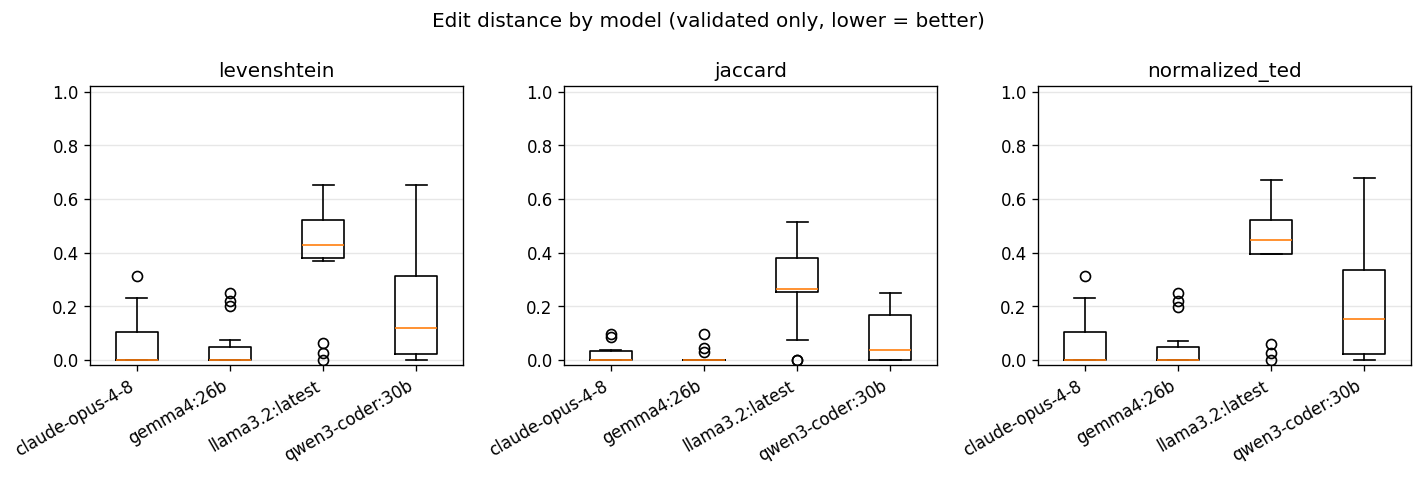

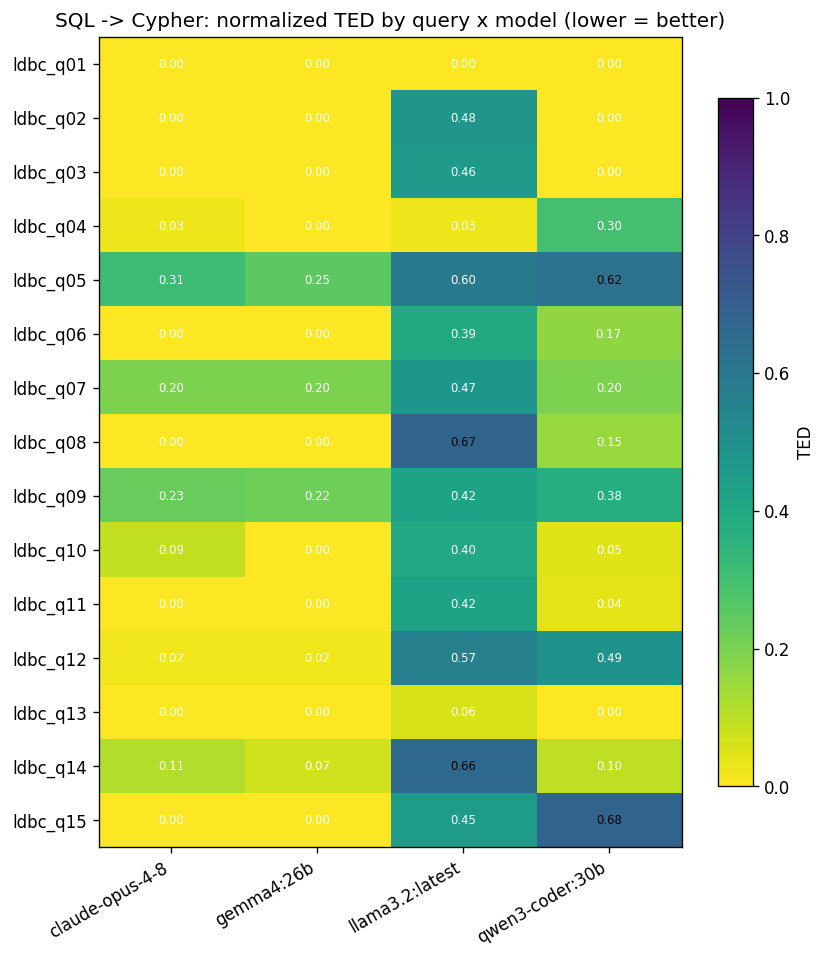

In [9]:
plots.render_target(dist_df[dist_df['target'] == 'cypher'], 'cypher', 'SQL -> Cypher', plots.FIGURE_SETS['distance'])

### Aggregation by model

In [10]:
summarize_target('cypher')

,levenshtein,jaccard,normalized_ted
model,,,
claude-opus-4-8,0.066417,0.018580,0.066173
gemma4:26b,0.050895,0.011370,0.050576
llama3.2:latest,0.395912,0.282476,0.404789
qwen3-coder:30b,0.202439,0.091002,0.210969


## SQL → AQL

### llama3.2:latest

In [11]:
show_model('aql', 'llama3.2:latest')

,query_id,difficulty,levenshtein,jaccard,normalized_ted
0,ldbc_q01,easy,0.023810,0.105263,0.023256
1,ldbc_q02,easy,0.078947,0.181818,0.076923
2,ldbc_q03,easy,0.066667,0.222222,0.064516
3,ldbc_q04,hard,0.380000,0.281250,0.392157
4,ldbc_q05,hard,0.507463,0.410256,0.544118
5,ldbc_q06,medium,0.407407,0.406250,0.436364
6,ldbc_q07,medium,0.333333,0.314286,0.342466
7,ldbc_q08,hard,0.690789,0.549020,0.738562
8,ldbc_q09,medium,0.513514,0.428571,0.533333
9,ldbc_q10,hard,0.367347,0.363636,0.380000


### qwen3-coder:30b

In [12]:
show_model('aql', 'qwen3-coder:30b')

,query_id,difficulty,levenshtein,jaccard,normalized_ted
0,ldbc_q01,easy,0.071429,0.142857,0.069767
1,ldbc_q02,easy,0.027778,0.050000,0.027027
2,ldbc_q03,easy,0.100000,0.210526,0.096774
3,ldbc_q04,hard,0.622951,0.285714,0.645161
4,ldbc_q05,hard,0.507246,0.342105,0.542857
5,ldbc_q06,medium,0.166667,0.192308,0.163265
6,ldbc_q07,medium,0.220588,0.156250,0.246377
7,ldbc_q08,hard,0.290323,0.181818,0.287234
8,ldbc_q09,medium,0.445946,0.378378,0.453333
9,ldbc_q10,hard,0.295455,0.080000,0.288889


### gemma4:26b

In [13]:
show_model('aql', 'gemma4:26b')

,query_id,difficulty,levenshtein,jaccard,normalized_ted
0,ldbc_q01,easy,0.000000,0.000000,0.000000
1,ldbc_q02,easy,0.000000,0.000000,0.000000
2,ldbc_q03,easy,0.000000,0.000000,0.000000
3,ldbc_q04,hard,0.622222,0.393939,0.652174
4,ldbc_q05,hard,0.322034,0.243243,0.316667
5,ldbc_q06,medium,0.125000,0.120000,0.122449
6,ldbc_q07,medium,0.117647,0.035714,0.115942
7,ldbc_q08,hard,0.333333,0.222222,0.361702
8,ldbc_q09,medium,0.405405,0.305556,0.400000
9,ldbc_q10,hard,0.355556,0.080000,0.347826


### claude-opus-4-8

In [14]:
show_model('aql', 'claude-opus-4-8')

,query_id,difficulty,levenshtein,jaccard,normalized_ted
0,ldbc_q01,easy,0.071429,0.142857,0.069767
1,ldbc_q02,easy,0.000000,0.000000,0.000000
2,ldbc_q03,easy,0.033333,0.117647,0.032258
3,ldbc_q04,hard,0.282609,0.074074,0.276596
4,ldbc_q05,hard,0.481013,0.270270,0.500000
5,ldbc_q06,medium,0.125000,0.120000,0.122449
6,ldbc_q07,medium,0.147059,0.100000,0.144928
7,ldbc_q08,hard,0.193548,0.100000,0.191489
8,ldbc_q09,medium,0.405405,0.305556,0.400000
9,ldbc_q10,hard,0.295455,0.080000,0.288889


### Visualizations

SQL -> AQL: 4 model(s), 15 query id(s)


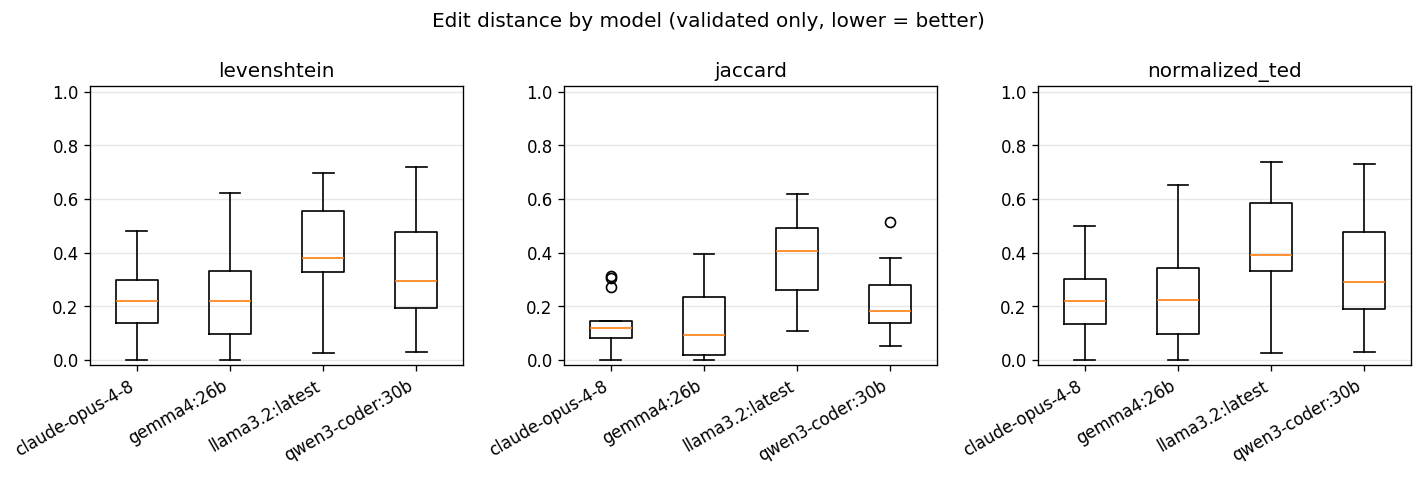

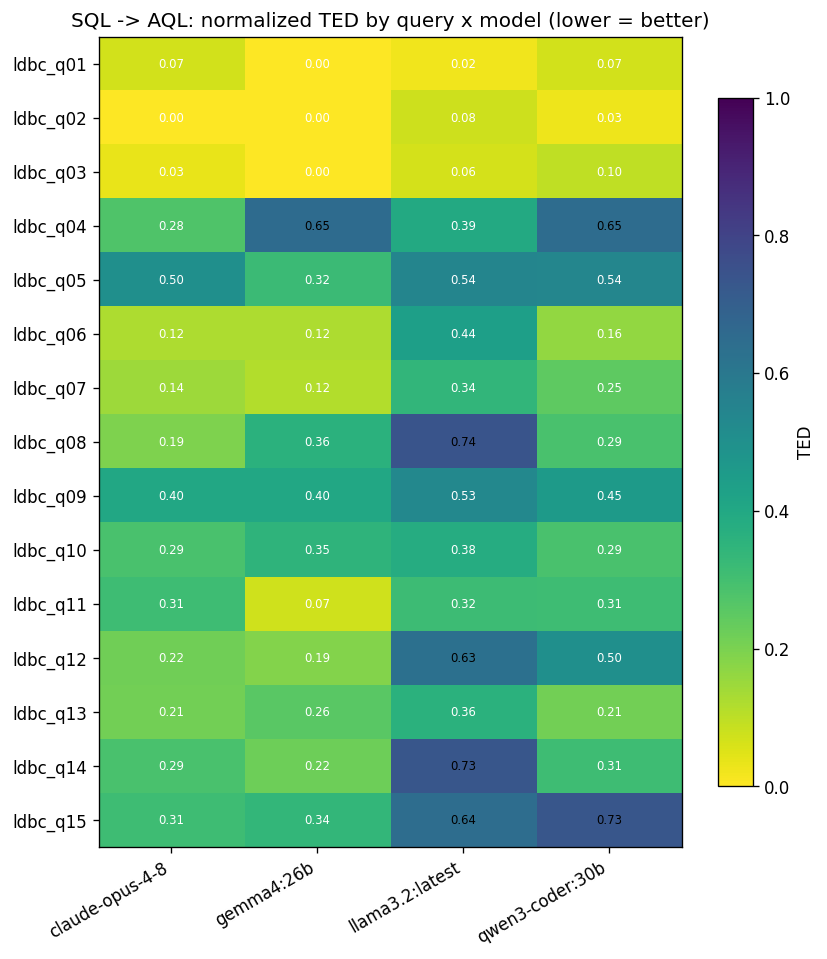

In [15]:
plots.render_target(dist_df[dist_df['target'] == 'aql'], 'aql', 'SQL -> AQL', plots.FIGURE_SETS['distance'])

### Aggregation by model

In [16]:
summarize_target('aql')

,levenshtein,jaccard,normalized_ted
model,,,
claude-opus-4-8,0.225533,0.136637,0.224506
gemma4:26b,0.221080,0.135399,0.226171
llama3.2:latest,0.398245,0.380687,0.414359
qwen3-coder:30b,0.321504,0.210901,0.325791


## SQL → Gremlin

### llama3.2:latest

In [17]:
show_model('gremlin', 'llama3.2:latest')

,query_id,difficulty,levenshtein,jaccard,normalized_ted
0,ldbc_q01,easy,0.423077,0.277778,0.391304
1,ldbc_q02,easy,0.573333,0.555556,0.970588
2,ldbc_q03,easy,0.447368,0.200000,0.470588
3,ldbc_q04,hard,0.535714,0.500000,0.800000
4,ldbc_q05,hard,0.655172,0.574468,0.836066
5,ldbc_q06,medium,0.675325,0.481481,0.870968
6,ldbc_q07,medium,0.682927,0.660000,0.897059
7,ldbc_q08,hard,0.448052,0.441176,0.619048
8,ldbc_q09,medium,0.635593,0.457143,0.693878
9,ldbc_q10,hard,0.541176,0.413793,0.594595


### qwen3-coder:30b

In [18]:
show_model('gremlin', 'qwen3-coder:30b')

,query_id,difficulty,levenshtein,jaccard,normalized_ted
0,ldbc_q01,easy,0.057692,0.157895,0.130435
1,ldbc_q02,easy,0.226667,0.208333,0.218750
2,ldbc_q03,easy,0.170732,0.176471,0.277778
3,ldbc_q04,hard,0.554745,0.241379,0.703704
4,ldbc_q05,hard,0.603175,0.342857,0.800000
5,ldbc_q06,medium,0.441558,0.423077,0.612903
6,ldbc_q07,medium,0.518293,0.228571,0.544118
7,ldbc_q08,hard,0.873150,0.630769,0.942257
8,ldbc_q09,medium,0.500000,0.228571,0.734694
9,ldbc_q10,hard,0.559322,0.200000,0.617021


### gemma4:26b

In [19]:
show_model('gremlin', 'gemma4:26b')

,query_id,difficulty,levenshtein,jaccard,normalized_ted
0,ldbc_q01,easy,0.145455,0.200000,0.250000
1,ldbc_q02,easy,0.226667,0.208333,0.218750
2,ldbc_q03,easy,0.121951,0.066667,0.166667
3,ldbc_q04,hard,0.081081,0.125000,0.100000
4,ldbc_q05,hard,0.369048,0.111111,0.382353
5,ldbc_q06,medium,0.345794,0.250000,0.454545
6,ldbc_q07,medium,0.091463,0.157895,0.117647
7,ldbc_q08,hard,0.097403,0.088235,0.126984
8,ldbc_q09,medium,0.304965,0.200000,0.465517
9,ldbc_q10,hard,0.084746,0.050000,0.083333


### claude-opus-4-8

In [20]:
show_model('gremlin', 'claude-opus-4-8')

,query_id,difficulty,levenshtein,jaccard,normalized_ted
0,ldbc_q01,easy,0.057692,0.157895,0.130435
1,ldbc_q02,easy,0.240000,0.240000,0.250000
2,ldbc_q03,easy,0.170732,0.176471,0.277778
3,ldbc_q04,hard,0.135135,0.043478,0.133333
4,ldbc_q05,hard,0.098592,0.083333,0.103448
5,ldbc_q06,medium,0.415584,0.320000,0.612903
6,ldbc_q07,medium,0.085366,0.135135,0.102941
7,ldbc_q08,hard,0.344156,0.093750,0.412698
8,ldbc_q09,medium,0.516949,0.200000,0.938776
9,ldbc_q10,hard,0.000000,0.000000,0.000000


### Visualizations

SQL -> Gremlin: 4 model(s), 15 query id(s)


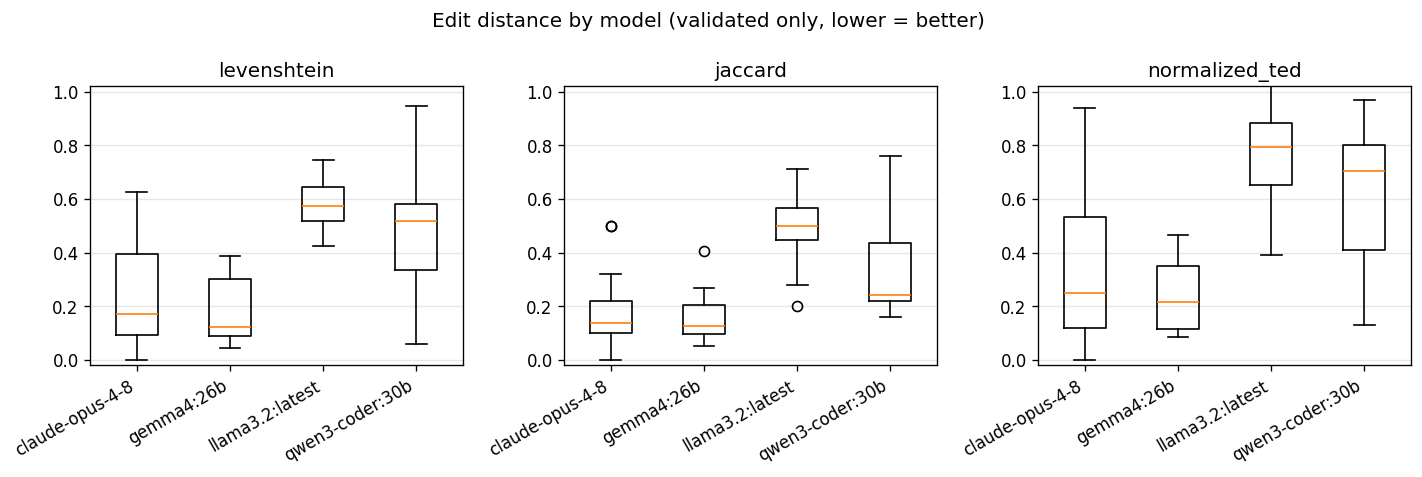

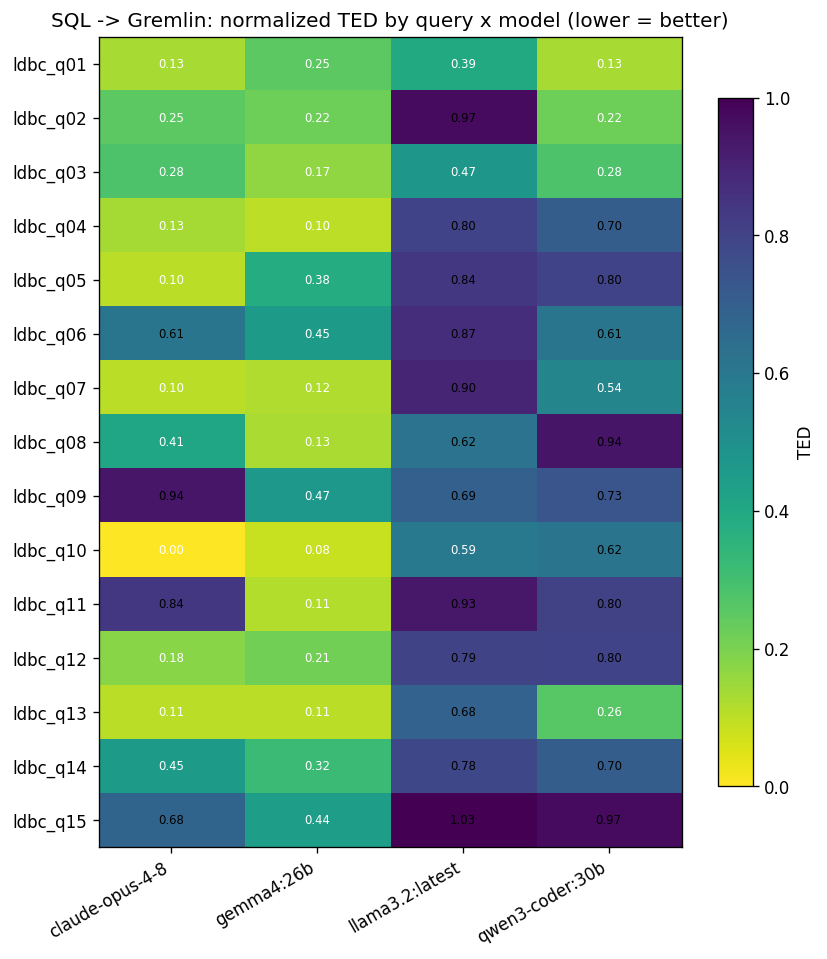

In [21]:
plots.render_target(dist_df[dist_df['target'] == 'gremlin'], 'gremlin', 'SQL -> Gremlin', plots.FIGURE_SETS['distance'])

### Aggregation by model

In [22]:
summarize_target('gremlin')

,levenshtein,jaccard,normalized_ted
model,,,
claude-opus-4-8,0.244464,0.185498,0.347667
gemma4:26b,0.186551,0.161961,0.237387
llama3.2:latest,0.572105,0.494409,0.757825
qwen3-coder:30b,0.490007,0.352235,0.608045


## Run-level summary (lower is better)

The whole matrix at a glance: the per-cell (dataset x target x model) means and the difficulty stratification. No cross-target average is computed; targets are never mixed.

In [23]:
print('By dataset x target x model:')
display(dist_df.groupby(['dataset','target','model'])[metric_cols].mean())
print('By target x difficulty:')
_bd = dist_df.copy()
_bd['difficulty'] = pd.Categorical(_bd['difficulty'], ['easy','medium','hard'], ordered=True)
display(_bd.groupby(['target','difficulty'], observed=True)[metric_cols].mean())

By dataset x target x model:


levenshtein   jaccard  normalized_ted
dataset target  model                                                 
ldbc    aql     claude-opus-4-8     0.225533  0.136637        0.224506
                gemma4:26b          0.221080  0.135399        0.226171
                llama3.2:latest     0.398245  0.380687        0.414359
                qwen3-coder:30b     0.321504  0.210901        0.325791
        cypher  claude-opus-4-8     0.066417  0.018580        0.066173
                gemma4:26b          0.050895  0.011370        0.050576
                llama3.2:latest     0.395912  0.282476        0.404789
                qwen3-coder:30b     0.202439  0.091002        0.210969
        gremlin claude-opus-4-8     0.244464  0.185498        0.347667
                gemma4:26b          0.186551  0.161961        0.237387
                llama3.2:latest     0.572105  0.494409        0.757825
                qwen3-coder:30b     0.490007  0.352235        0.608045

By target x difficulty:


levenshtein   jaccard  normalized_ted
target  difficulty                                       
aql     easy           0.039449  0.097766        0.038357
        medium         0.309300  0.232215        0.314779
        hard           0.377289  0.252054        0.386427
cypher  easy           0.080400  0.071573        0.078618
        medium         0.231753  0.124173        0.238072
        hard           0.189441  0.100181        0.194845
gremlin easy           0.238447  0.218783        0.312756
        medium         0.431251  0.365935        0.581749
        hard           0.394860  0.294725        0.506338

## Save per-record CSV

In [24]:
dist_df.to_csv(OUT_CSV, index=False)
print(f'Wrote {len(dist_df)} rows to {OUT_CSV}')

Wrote 180 rows to /Users/ivona.obonova/school/rows2graph/rows2graph/eval/outputs/metrics/metrics_distance.csv
